# ❤️ Heart Disease Risk Prediction
### By Pritesh Raj | Roll No: 230103035
### IIIT Senapati, Manipur
---
**Dataset:** Framingham Heart Study Dataset  
**Records:** 4,240 patients  
**Features:** 15 clinical & lifestyle parameters  
**Target:** TenYearCHD (10-Year Coronary Heart Disease Risk: 0=No, 1=Yes)

## Step 1: Import All Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset

In [2]:
df = pd.read_csv('framingham.csv')
print('Dataset Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Dataset Shape: (4240, 16)

Columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Step 3: Understand the Dataset

In [3]:
feature_info = {
    'male':            'Gender (1=Male, 0=Female)',
    'age':             'Age of the patient (years)',
    'education':       'Education level (1-4)',
    'currentSmoker':   'Current smoker (1=Yes, 0=No)',
    'cigsPerDay':      'Cigarettes smoked per day',
    'BPMeds':          'On Blood Pressure medication (1=Yes)',
    'prevalentStroke': 'History of stroke (1=Yes)',
    'prevalentHyp':    'Hypertensive (1=Yes)',
    'diabetes':        'Has diabetes (1=Yes)',
    'totChol':         'Total cholesterol (mg/dL)',
    'sysBP':           'Systolic blood pressure (mm Hg)',
    'diaBP':           'Diastolic blood pressure (mm Hg)',
    'BMI':             'Body Mass Index (kg/m²)',
    'heartRate':       'Heart rate (beats/min)',
    'glucose':         'Blood glucose level (mg/dL)',
    'TenYearCHD':      'TARGET: 10-Year Heart Disease Risk (0=No, 1=Yes)'
}

print('Feature Descriptions:')
print('='*65)
for feat, desc in feature_info.items():
    print(f'{feat:<18} : {desc}')

print('\nBasic Statistics:')
df.describe()

Feature Descriptions:
male               : Gender (1=Male, 0=Female)
age                : Age of the patient (years)
education          : Education level (1-4)
currentSmoker      : Current smoker (1=Yes, 0=No)
cigsPerDay         : Cigarettes smoked per day
BPMeds             : On Blood Pressure medication (1=Yes)
prevalentStroke    : History of stroke (1=Yes)
prevalentHyp       : Hypertensive (1=Yes)
diabetes           : Has diabetes (1=Yes)
totChol            : Total cholesterol (mg/dL)
sysBP              : Systolic blood pressure (mm Hg)
diaBP              : Diastolic blood pressure (mm Hg)
BMI                : Body Mass Index (kg/m²)
heartRate          : Heart rate (beats/min)
glucose            : Blood glucose level (mg/dL)
TenYearCHD         : TARGET: 10-Year Heart Disease Risk (0=No, 1=Yes)

Basic Statistics:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## Step 4: Exploratory Data Analysis (EDA)

Target (TenYearCHD) Distribution:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64

No Heart Disease: 3596 (84.8%)
Heart Disease:    644 (15.2%)


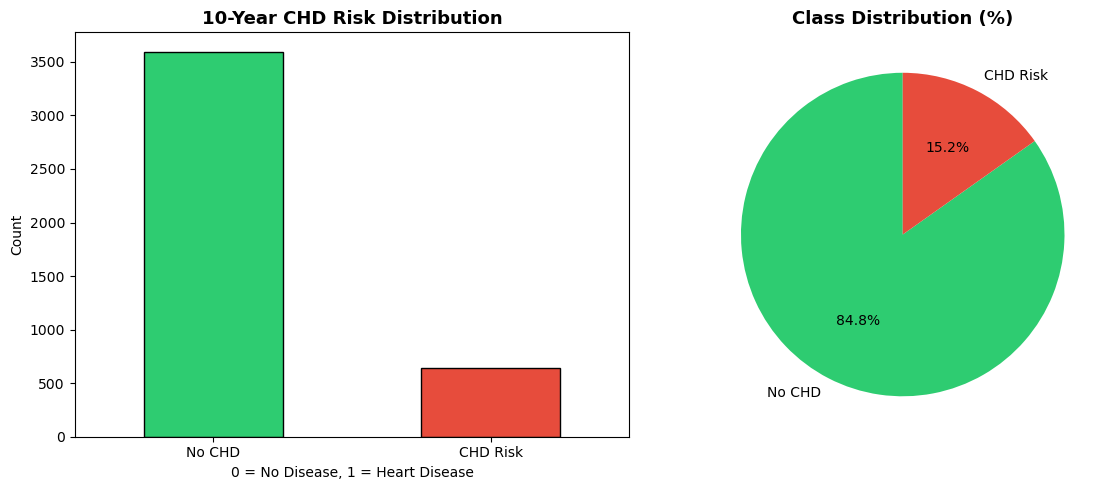

In [4]:
# Class distribution
print('Target (TenYearCHD) Distribution:')
print(df['TenYearCHD'].value_counts())
no_chd  = (df['TenYearCHD'] == 0).sum()
yes_chd = (df['TenYearCHD'] == 1).sum()
print(f'\nNo Heart Disease: {no_chd} ({no_chd/len(df)*100:.1f}%)')
print(f'Heart Disease:    {yes_chd} ({yes_chd/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
df['TenYearCHD'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('10-Year CHD Risk Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('0 = No Disease, 1 = Heart Disease')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No CHD','CHD Risk'], rotation=0)

# Pie chart
axes[1].pie([no_chd, yes_chd],
            labels=['No CHD','CHD Risk'],
            colors=['#2ecc71','#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('heart_fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

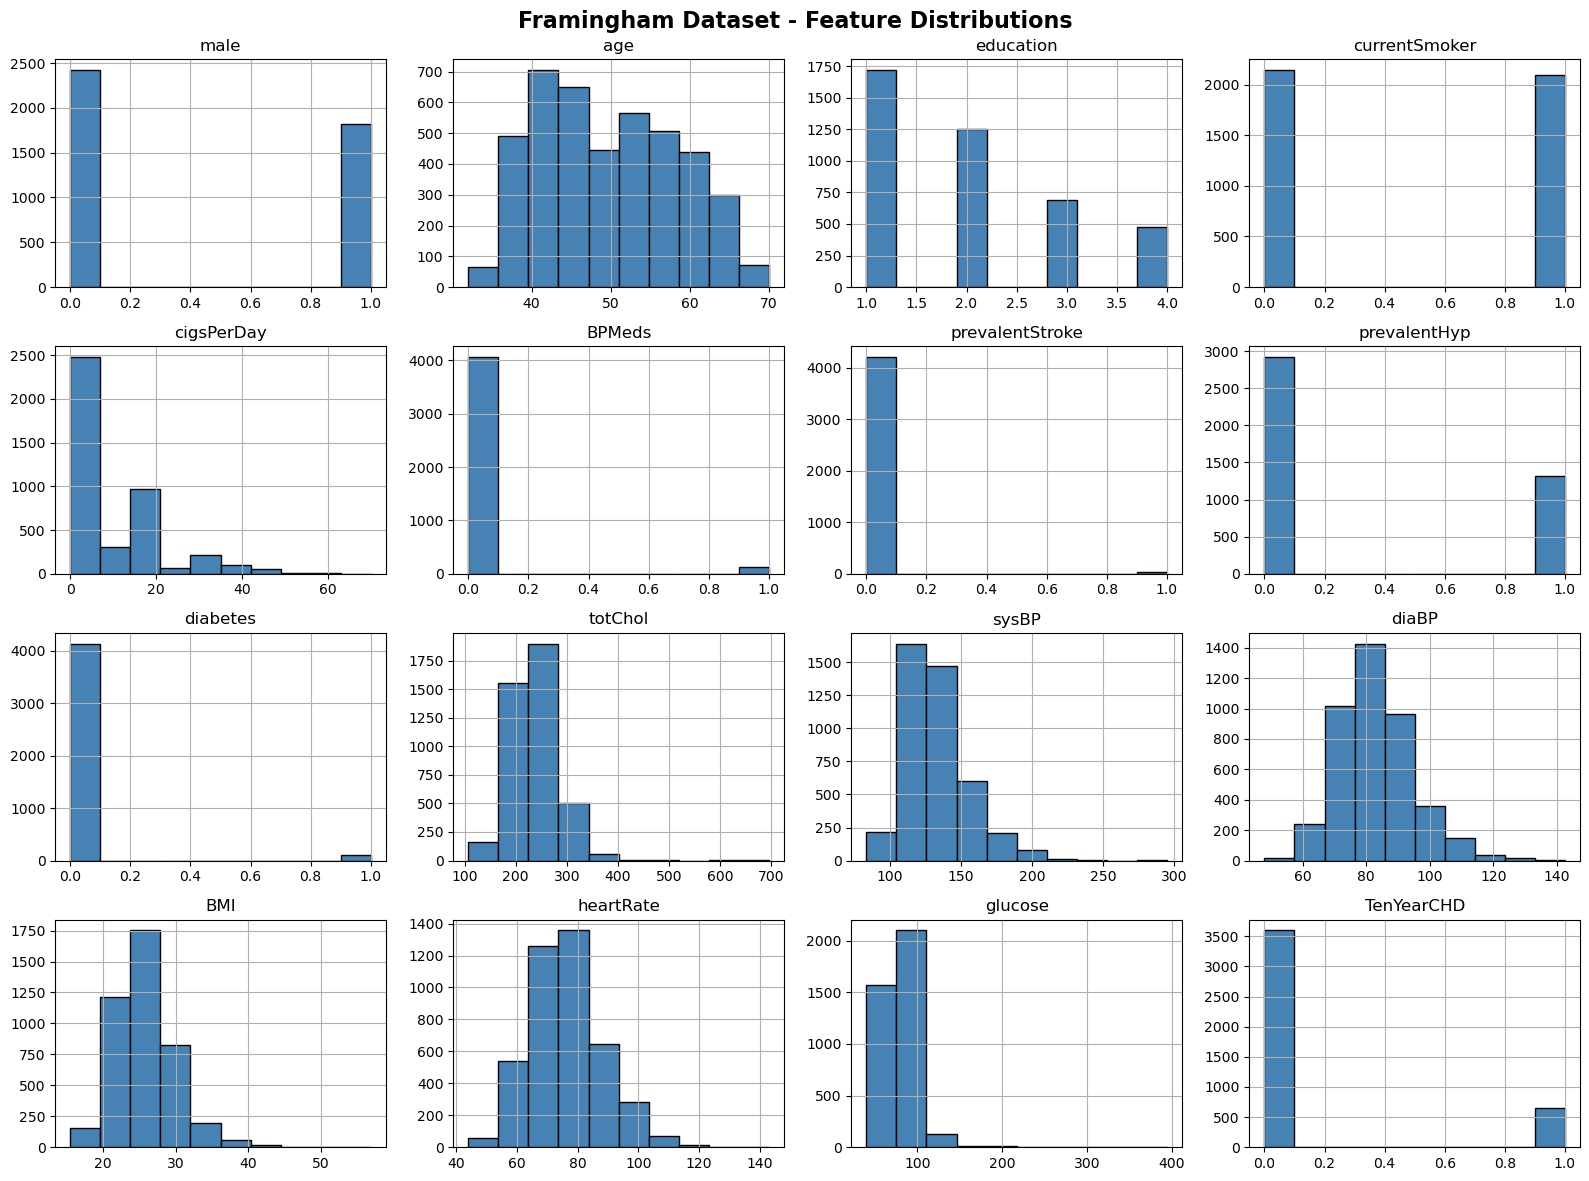

In [5]:
# Feature distributions
df.hist(figsize=(16, 12), color='steelblue', edgecolor='black')
plt.suptitle('Framingham Dataset - Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_fig2_feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

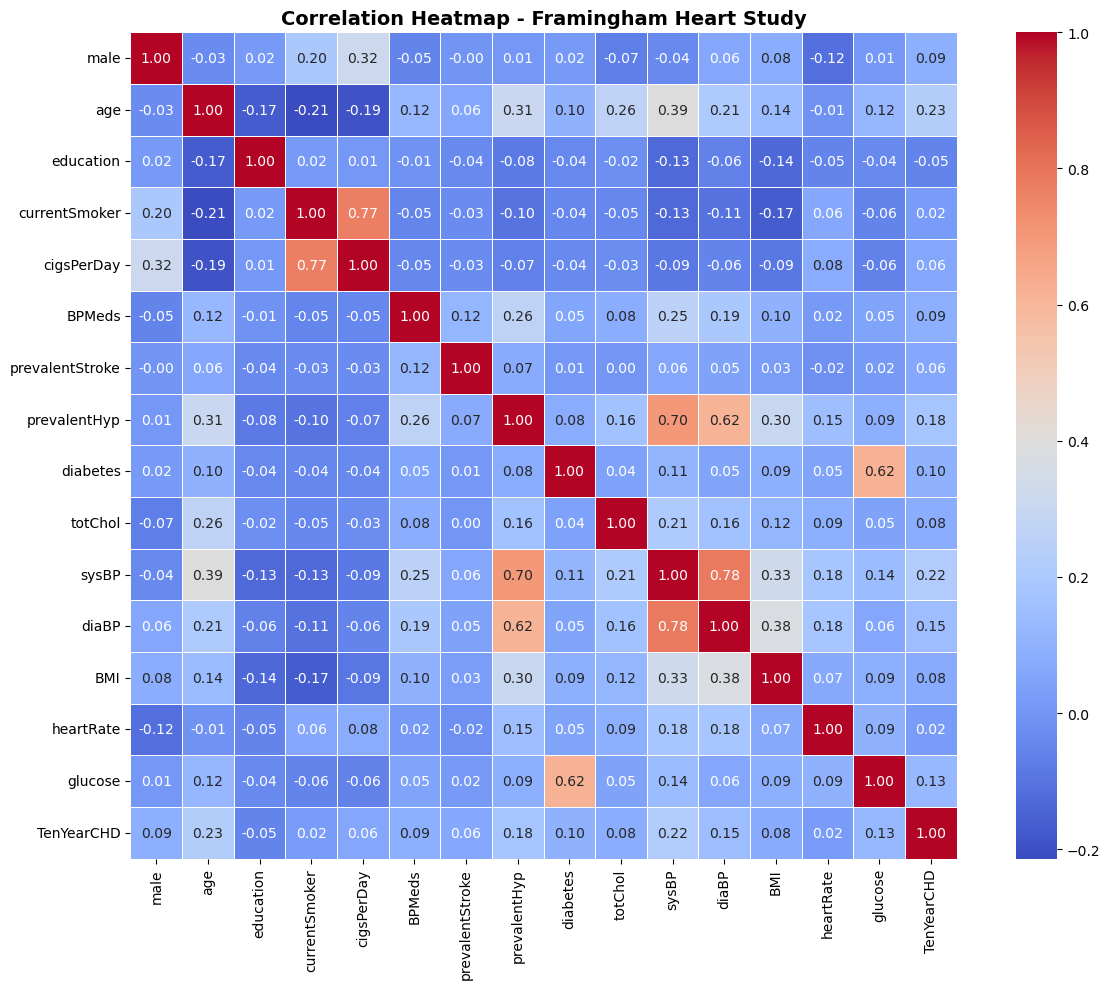

In [6]:
# Correlation Heatmap
plt.figure(figsize=(13, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Framingham Heart Study',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

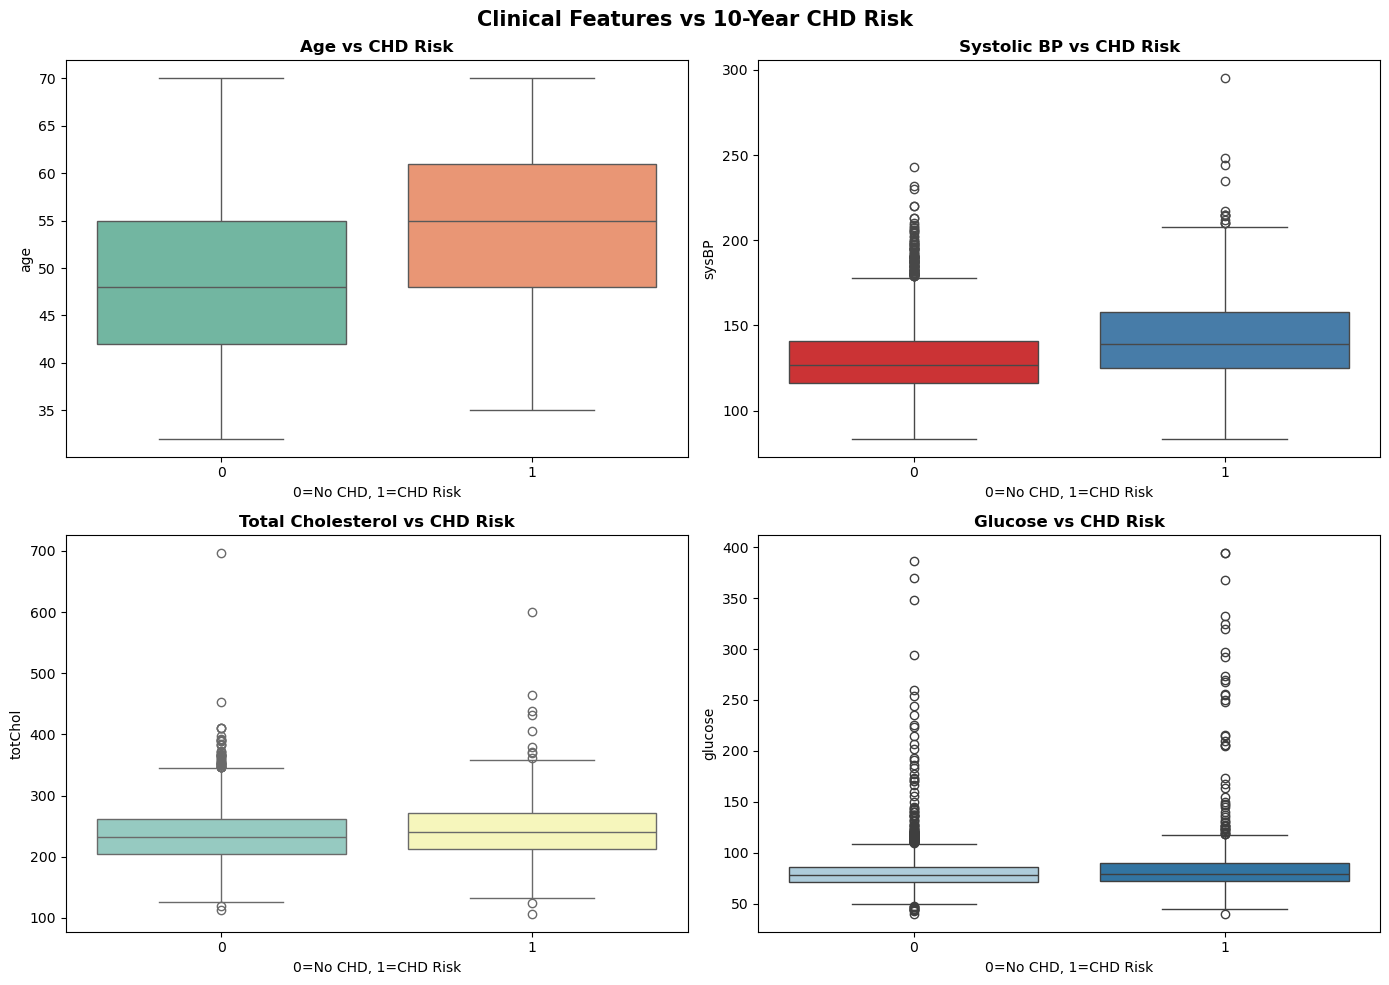

In [7]:
# Key clinical features vs Heart Disease
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='TenYearCHD', y='age',      data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Age vs CHD Risk',            fontweight='bold')
axes[0,0].set_xlabel('0=No CHD, 1=CHD Risk')

sns.boxplot(x='TenYearCHD', y='sysBP',    data=df, palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Systolic BP vs CHD Risk',    fontweight='bold')
axes[0,1].set_xlabel('0=No CHD, 1=CHD Risk')

sns.boxplot(x='TenYearCHD', y='totChol',  data=df, palette='Set3', ax=axes[1,0])
axes[1,0].set_title('Total Cholesterol vs CHD Risk', fontweight='bold')
axes[1,0].set_xlabel('0=No CHD, 1=CHD Risk')

sns.boxplot(x='TenYearCHD', y='glucose',  data=df, palette='Paired', ax=axes[1,1])
axes[1,1].set_title('Glucose vs CHD Risk',         fontweight='bold')
axes[1,1].set_xlabel('0=No CHD, 1=CHD Risk')

plt.suptitle('Clinical Features vs 10-Year CHD Risk',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_fig4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Data Cleaning - Handle Missing Values

In [8]:
print('Missing values before cleaning:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# Fill numerical columns with median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print('\nMissing values after cleaning:')
print(df.isnull().sum())
print('\nData cleaning complete!')

Missing values before cleaning:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Total missing: 645

Missing values after cleaning:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

Data cleaning complete!


## Step 6: Feature Engineering

In [9]:
# Add new engineered features for better accuracy
# Pulse Pressure = Systolic - Diastolic (important heart health indicator)
df['pulse_pressure'] = df['sysBP'] - df['diaBP']

# Smoking intensity category
df['heavy_smoker'] = (df['cigsPerDay'] > 20).astype(int)

# Age group risk
df['age_risk'] = pd.cut(df['age'],
                         bins=[0, 40, 50, 60, 100],
                         labels=[0, 1, 2, 3]).astype(int)

# BMI category
df['bmi_category'] = pd.cut(df['BMI'],
                              bins=[0, 18.5, 25, 30, 100],
                              labels=[0, 1, 2, 3]).astype(int)

print('New features added:')
print('  pulse_pressure : Systolic BP - Diastolic BP')
print('  heavy_smoker   : Smokes > 20 cigs/day')
print('  age_risk       : Age group category (0-3)')
print('  bmi_category   : BMI category (Underweight/Normal/Overweight/Obese)')
print(f'\nNew dataset shape: {df.shape}')

New features added:
  pulse_pressure : Systolic BP - Diastolic BP
  heavy_smoker   : Smokes > 20 cigs/day
  age_risk       : Age group category (0-3)
  bmi_category   : BMI category (Underweight/Normal/Overweight/Obese)

New dataset shape: (4240, 20)


## Step 7: Data Preparation

In [10]:
# Separate features and target
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Train-test split 80:20 with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Total samples:    {len(df)}')
print(f'Training samples: {X_train_scaled.shape[0]}')
print(f'Testing samples:  {X_test_scaled.shape[0]}')
print(f'Total features:   {X_train_scaled.shape[1]}')
print('\nData preparation complete!')

Total samples:    4240
Training samples: 3392
Testing samples:  848
Total features:   19

Data preparation complete!


## Step 8: Handle Class Imbalance using SMOTE

In [12]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {len(X_train_scaled)} samples')
print(f'After SMOTE:  {len(X_train_sm)} samples')
print(f'\nClass distribution after SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Before SMOTE: 3392 samples
After SMOTE:  5754 samples

Class distribution after SMOTE:
TenYearCHD
0    2877
1    2877
Name: count, dtype: int64


## Step 9: Train and Compare All ML Models

In [14]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(
        n_estimators=200, max_depth=8,
        min_samples_split=5, random_state=42),
    'SVM':                 SVC(
        C=1.0, kernel='rbf', gamma='scale',
        probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(
        n_neighbors=7, weights='distance'),
    'XGBoost':             XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', verbosity=0),
    'Gradient Boosting':   GradientBoostingClassifier(
        n_estimators=300, max_depth=4,
        learning_rate=0.05, subsample=0.8,
        random_state=42),
    'Voting Ensemble':     VotingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(
                        n_estimators=200, max_depth=8, random_state=42)),
            ('gb',  GradientBoostingClassifier(
                        n_estimators=300, max_depth=4,
                        learning_rate=0.05, subsample=0.8, random_state=42)),
            ('xgb', XGBClassifier(
                        n_estimators=300, max_depth=5, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, eval_metric='logloss', verbosity=0)),
            ('lr',  LogisticRegression(
                        C=1.0, max_iter=1000, random_state=42)),
            ('svm', SVC(
                        C=1.0, kernel='rbf', gamma='scale',
                        probability=True, random_state=42))
        ],
        voting='soft'
    )
}

results    = {}
cv_results = {}
roc_scores = {}

print('Training all models...')
print('='*70)

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, X_train_sm, y_train_sm,
                          cv=5, scoring='accuracy')

    results[name]    = acc
    cv_results[name] = cv.mean()
    roc_scores[name] = auc

    print(f'{name:<22}  Acc: {acc*100:.2f}%  |  AUC: {auc:.3f}  |  CV: {cv.mean()*100:.2f}%')

print('='*70)
best_model_name = max(results, key=results.get)
print(f'\nBest Model: {best_model_name} ({results[best_model_name]*100:.2f}%)')

Training all models...
Logistic Regression     Acc: 66.98%  |  AUC: 0.697  |  CV: 68.56%
Random Forest           Acc: 73.58%  |  AUC: 0.660  |  CV: 82.05%
SVM                     Acc: 68.75%  |  AUC: 0.617  |  CV: 75.01%
KNN                     Acc: 61.32%  |  AUC: 0.592  |  CV: 80.74%
XGBoost                 Acc: 81.37%  |  AUC: 0.618  |  CV: 87.26%
Gradient Boosting       Acc: 80.31%  |  AUC: 0.628  |  CV: 86.60%
Voting Ensemble         Acc: 75.24%  |  AUC: 0.659  |  CV: 84.50%

Best Model: XGBoost (81.37%)


## Step 10: Model Comparison Graphs

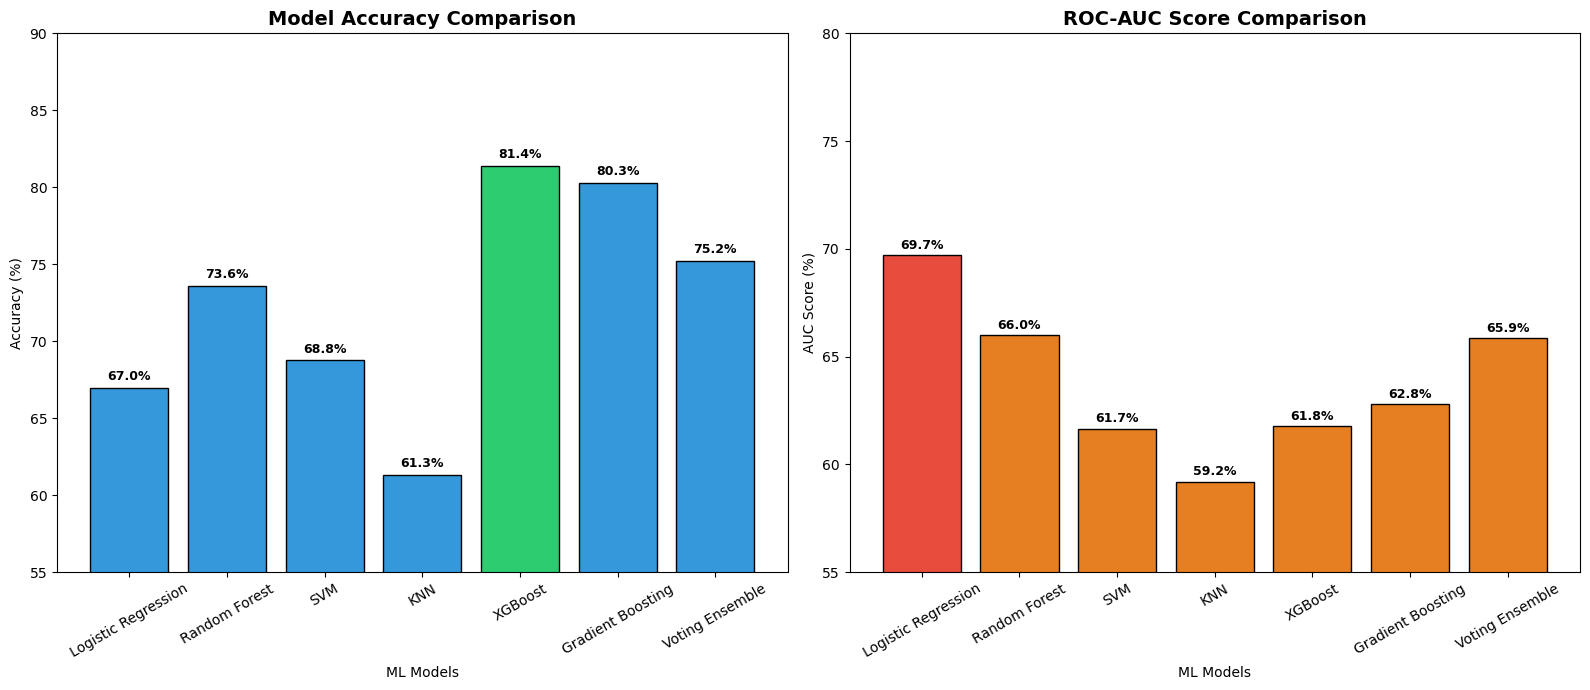

Graph saved!


In [18]:
# Step 10 - Model Comparison Graphs
model_names = list(results.keys())
accuracies  = [v * 100 for v in results.values()]
auc_vals    = [v * 100 for v in roc_scores.values()]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Accuracy bar chart - FIXED
colors1 = ['#2ecc71' if v == max(accuracies) else '#3498db' for v in accuracies]
bars1 = axes[0].bar(model_names, accuracies, color=colors1, edgecolor='black')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ML Models')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([55, 90])  # Fixed range
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center',
                 fontweight='bold', fontsize=9)

# AUC bar chart - FIXED
colors2 = ['#e74c3c' if v == max(auc_vals) else '#e67e22' for v in auc_vals]
bars2 = axes[1].bar(model_names, auc_vals, color=colors2, edgecolor='black')
axes[1].set_title('ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ML Models')
axes[1].set_ylabel('AUC Score (%)')
axes[1].set_ylim([55, 80])  # Fixed range
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, auc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center',
                 fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('heart_fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved!")

## Step 11: Best Model - Detailed Analysis

In [19]:
best_model   = models[best_model_name]
y_pred_final = best_model.predict(X_test_scaled)
y_prob_final = best_model.predict_proba(X_test_scaled)[:, 1]

print(f'Best Model     : {best_model_name}')
print(f'Test Accuracy  : {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print(f'ROC-AUC Score  : {roc_auc_score(y_test, y_prob_final):.4f}')
print('='*60)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final,
      target_names=['No CHD Risk', 'CHD Risk']))

Best Model     : XGBoost
Test Accuracy  : 81.37%
ROC-AUC Score  : 0.6178

Classification Report:
              precision    recall  f1-score   support

 No CHD Risk       0.86      0.92      0.89       719
    CHD Risk       0.32      0.19      0.24       129

    accuracy                           0.81       848
   macro avg       0.59      0.56      0.57       848
weighted avg       0.78      0.81      0.79       848



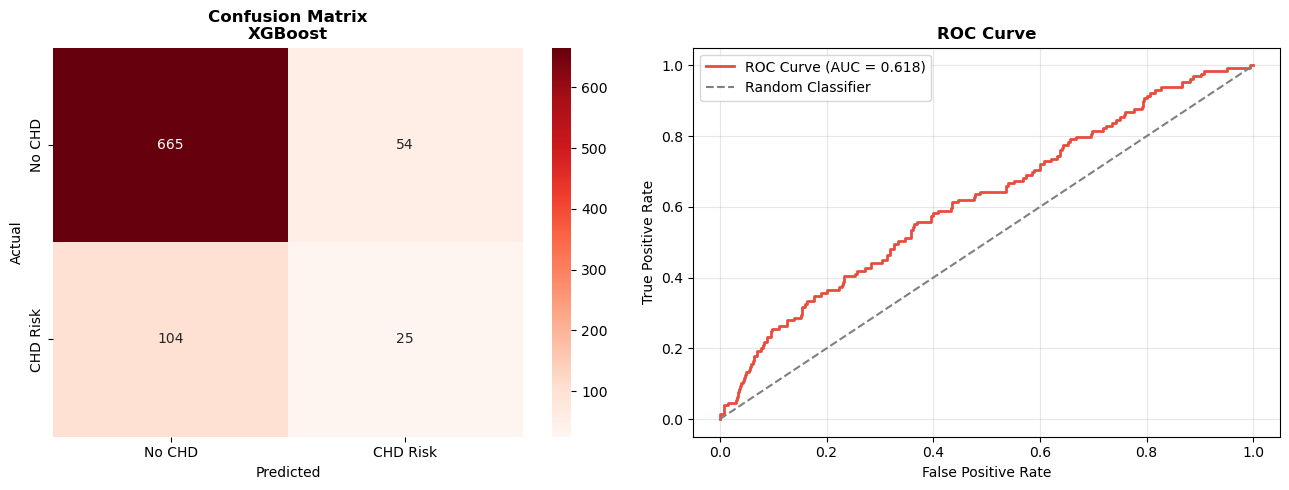

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No CHD', 'CHD Risk'],
            yticklabels=['No CHD', 'CHD Risk'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
auc_val = roc_auc_score(y_test, y_prob_final)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {auc_val:.3f})')
axes[1].plot([0,1], [0,1], color='gray', linestyle='--',
             label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('heart_fig6_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: UNIQUE FEATURE - Feature Importance Analysis
### Which factors matter most for 10-Year CHD Risk?

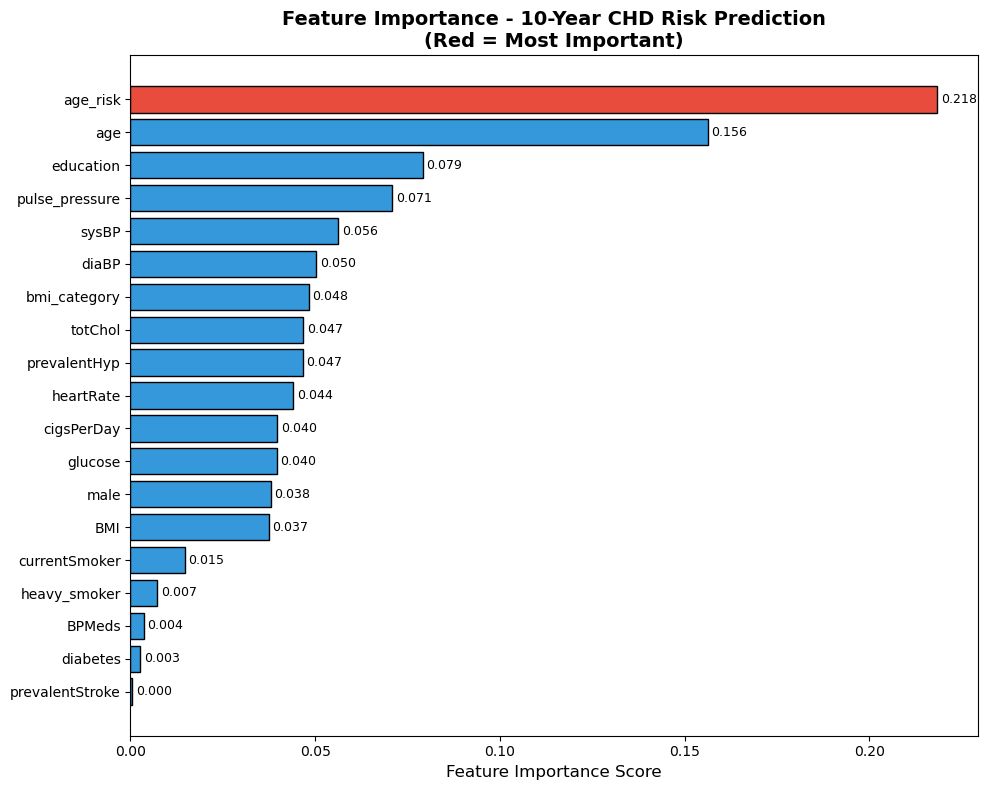

Top 5 Most Important Features for CHD Risk:
           Feature  Importance
17        age_risk    0.218334
1              age    0.156227
2        education    0.079049
15  pulse_pressure    0.070899
10           sysBP    0.056229


In [21]:
# Feature importance using Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

feature_names = X.columns.tolist()
importances   = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors_fi = ['#e74c3c' if v == feat_df['Importance'].max()
             else '#3498db' for v in feat_df['Importance']]
bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                color=colors_fi, edgecolor='black')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Feature Importance - 10-Year CHD Risk Prediction\n(Red = Most Important)',
          fontsize=14, fontweight='bold')
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('heart_fig7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 Most Important Features for CHD Risk:')
print(feat_df.sort_values('Importance', ascending=False).head())

## Step 13: UNIQUE FEATURE - 10-Year CHD Risk Score Calculator
### Patient gets a 0-100 risk score with severity level + lifestyle advice

In [22]:
def calculate_chd_risk(probability):
    """Convert probability to risk score with level and advice."""
    score = round(probability * 100, 1)
    if score < 10:
        level   = 'LOW RISK'
        advice  = [
            'Maintain current healthy lifestyle',
            'Regular exercise (30 min/day)',
            'Annual health check-up'
        ]
    elif score < 20:
        level   = 'MODERATE RISK'
        advice  = [
            'Consult doctor for check-up',
            'Reduce salt and fat intake',
            'Monitor blood pressure regularly',
            'Quit smoking if applicable'
        ]
    elif score < 40:
        level   = 'HIGH RISK'
        advice  = [
            'Immediate medical consultation needed',
            'Strict diet control required',
            'Daily BP and glucose monitoring',
            'Consider medication if prescribed',
            'Stop smoking completely'
        ]
    else:
        level   = 'CRITICAL RISK'
        advice  = [
            'URGENT: See a cardiologist immediately',
            'Strict medical supervision required',
            'Emergency lifestyle changes needed',
            'Regular ECG monitoring'
        ]
    return score, level, advice


# Sample patient test cases
# Features: male, age, education, currentSmoker, cigsPerDay, BPMeds,
#           prevalentStroke, prevalentHyp, diabetes, totChol,
#           sysBP, diaBP, BMI, heartRate, glucose,
#           pulse_pressure, heavy_smoker, age_risk, bmi_category

sample_patients = [
    {'name': 'Patient A - Low Risk (Young Healthy)',
     'data': [0, 35, 3, 0, 0, 0, 0, 0, 0, 180, 110, 70, 22, 70, 80, 40, 0, 0, 1]},
    {'name': 'Patient B - Moderate Risk (Middle Aged)',
     'data': [1, 50, 2, 1, 10, 0, 0, 1, 0, 230, 130, 85, 27, 80, 100, 45, 0, 2, 1]},
    {'name': 'Patient C - High Risk (Smoker + Hypertension)',
     'data': [1, 60, 1, 1, 25, 1, 0, 1, 1, 270, 155, 95, 31, 90, 140, 60, 1, 3, 2]},
]

print('10-Year Coronary Heart Disease Risk Assessment')
print('='*60)
for patient in sample_patients:
    input_arr    = np.array(patient['data']).reshape(1, -1)
    input_scaled = scaler.transform(input_arr)
    probability  = best_model.predict_proba(input_scaled)[0][1]
    score, level, advice = calculate_chd_risk(probability)

    print(f"\n{patient['name']}")
    print(f'  10-Year CHD Risk Score : {score}/100')
    print(f'  Risk Level             : {level}')
    print('  Recommendations:')
    for tip in advice:
        print(f'    - {tip}')
print('\n' + '='*60)

10-Year Coronary Heart Disease Risk Assessment

Patient A - Low Risk (Young Healthy)
  10-Year CHD Risk Score : 1.2999999523162842/100
  Risk Level             : LOW RISK
  Recommendations:
    - Maintain current healthy lifestyle
    - Regular exercise (30 min/day)
    - Annual health check-up

Patient B - Moderate Risk (Middle Aged)
  10-Year CHD Risk Score : 13.5/100
  Risk Level             : MODERATE RISK
  Recommendations:
    - Consult doctor for check-up
    - Reduce salt and fat intake
    - Monitor blood pressure regularly
    - Quit smoking if applicable

Patient C - High Risk (Smoker + Hypertension)
  10-Year CHD Risk Score : 79.9000015258789/100
  Risk Level             : CRITICAL RISK
  Recommendations:
    - URGENT: See a cardiologist immediately
    - Strict medical supervision required
    - Emergency lifestyle changes needed
    - Regular ECG monitoring



## Step 14: Save Final Heart Disease Model

In [24]:
pickle.dump(best_model, open('heart_model.pkl',  'wb'))
pickle.dump(scaler,     open('heart_scaler.pkl', 'wb'))

print(f'Heart model saved  : heart_model.pkl  ({best_model_name})')
print('Heart scaler saved : heart_scaler.pkl')
print(f'\nFinal Accuracy     : {results[best_model_name]*100:.2f}%')
print(f'Final AUC Score    : {roc_scores[best_model_name]:.4f}')



Heart model saved  : heart_model.pkl  (XGBoost)
Heart scaler saved : heart_scaler.pkl

Final Accuracy     : 81.37%
Final AUC Score    : 0.6178
